# Notebook 03 — Modelo MVP


**Objetivo:** apoiar a elaboração do model card do modelo mvp descrito em `docs/model_card.md`.

## Imports e Setups

In [1]:
# Todo import de bibliotecas e configura??o de ambiente para rodar o notebook dever?o estar nesta c?lula.

import sys
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
from IPython.display import display
import yaml

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.exp import (
    build_artifact_name,
    build_campaign_retention_roi_grid,
    build_cross_validate_comparison_table,
    build_default_cv,
    build_default_scoring,
    build_economic_comparison_table,
    build_fairness_reports_bundle,
    build_notebook03_estimators,
    build_retention_roi_table,
    build_threshold_comparison_summary,
    compute_holdout_technical_metrics,
    compute_shap_summary_payload,
    consolidate_fairness_reports,
    extract_selected_feature_names,
    fit_final_estimator_and_generate_predictions,
    generate_oof_predictions_by_model,
    load_split_bundle_from_mlflow,
    optimize_threshold_for_roi,
    resolve_notebook03_runs,
    save_figure_temp,
    set_mlflow_tracking,
    summarize_calibration_for_models,
)
from src.utils.mlflow_tracking import ensure_experiment, log_dataframe_artifact, log_metrics_safe, start_experiment_run
from src.utils.plots import (
    plot_calibration_curves_grid,
    plot_confusion_matrix_threshold_comparison,
    plot_confusion_matrices_grid,
    plot_fairness_feature_subplot,
    plot_holdout_pr_roc_subplot,
    plot_learning_curves_grid,
    plot_pr_curves_grid,
    plot_probability_histograms_grid,
    plot_retention_vs_roi,
    plot_roi_by_threshold,
    plot_roi_heatmap,
    plot_roc_curves_grid,
    plot_shap_summary_subplot,
    plot_single_confusion_matrix,
    plot_single_probability_histogram,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

with open(PROJECT_ROOT / 'config' / 'config.yaml', encoding='utf-8') as f:
    config = yaml.safe_load(f)

TRACKING_URI = config['mlflow']['tracking_uri']
TARGET_COLUMN = config['data']['target']
INTERIM_DATA_PATH = PROJECT_ROOT / config['data']['interim_path']
MLFLOW_EXPERIMENT_NB03 = 'tc-f1-nb03-comparacao-modelos'
ACTIVATION_COST = 50.0
RETENTION_RATE = 0.10

client = set_mlflow_tracking(TRACKING_URI, workspace_root=PROJECT_ROOT)
cv = build_default_cv(
    n_splits=config['validation']['n_splits'],
    shuffle=config['validation']['shuffle'],
    random_state=config['experiment']['random_state'],
)
scoring = build_default_scoring()

print(f"Tracking URI: {TRACKING_URI}")
print(f"Target: {TARGET_COLUMN}")
print(f"Base intermedi?ria: {INTERIM_DATA_PATH}")
print(f"Experimento NB03: {MLFLOW_EXPERIMENT_NB03}")
print(f"Premissas econ?micas: custo por acionamento={ACTIVATION_COST:.0f} | reten??o={RETENTION_RATE:.2f}")


Tracking URI: sqlite:///mlflow.db
Target: Churn Value
Base intermedi?ria: C:\Users\jooar\ds\portfolio\mle-f1-tech-challenge-fiap\data\interim\telecom_clean.csv
Experimento NB03: tc-f1-nb03-comparacao-modelos
Campanha base: custo=100000 | reten??o=0.10


## Modelos em Comparação

- Regressão Logística (baseline inicial)
- MLP (baseline inicial)
- MLP Optuna
- XGBoost Optuna

## Recupera os Splits

In [2]:
split_bundle = load_split_bundle_from_mlflow(
    client=client,
    workspace_root=PROJECT_ROOT,
    data_path=INTERIM_DATA_PATH,
    target_column=TARGET_COLUMN,
)

X_train_val = split_bundle['X_train_val']
y_train_val = split_bundle['y_train_val']
X_test = split_bundle['X_test']
y_test = split_bundle['y_test']
metadata_train_val = split_bundle['metadata_train_val']
metadata_test = split_bundle['metadata_test']

print(f"X_train_val: {X_train_val.shape}")
print(f"y_train_val: {y_train_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
display(metadata_train_val.head())


X_train_val: (4930, 21)
y_train_val: (4930,)
X_test: (2113, 21)
y_test: (2113,)


,CLTV,CustomerID
index,,
5963,3391,6918-UMQCG
596,3561,4140-MUHUG
1836,2270,5570-PTWEH
3535,4159,2054-PJOCK
228,5559,4315-MURBD


## Recuperando os Experimentos do MLFlow

In [3]:
run_registry = resolve_notebook03_runs(client)
upstream_runs_by_model = {
    'LogisticRegression': run_registry['logistic_baseline'],
    'MLP': run_registry['mlp_baseline'],
    'MLP Optuna': run_registry['mlp_optuna'],
    'XGBoost Optuna': run_registry['xgb_optuna'],
}

run_summary = pd.DataFrame(
    [
        {
            'modelo': model_name,
            'run_name': run.data.tags.get('mlflow.runName'),
            'run_id': run.info.run_id,
            'artifact_uri': run.info.artifact_uri,
        }
        for model_name, run in upstream_runs_by_model.items()
    ]
)

display(run_summary)


,modelo,run_name,run_id,artifact_uri
0,LogisticRegression,LogisticRegression,c78614b2fdef444c9ba9fc2077e3a2dc,mlflow-artifacts:/1/c78614b2fdef444c9ba9fc2077...
1,MLP,MLP,22319ddeae8e46ef894043613ab5a299,mlflow-artifacts:/1/22319ddeae8e46ef894043613a...
2,MLP Optuna,optuna_mlp,3132d9b960c947afa75163c1ca0679b8,mlflow-artifacts:/6/3132d9b960c947afa75163c1ca...
3,XGBoost Optuna,optuna_xgboost,fa0896c73c3542d087cf8a3fad49a477,mlflow-artifacts:/6/fa0896c73c3542d087cf8a3fad...


## Refit e Geração de Probabilidades

In [4]:
comparison_models = build_notebook03_estimators(
    run_registry,
    workspace_root=PROJECT_ROOT,
    y_reference=y_train_val,
)

pd.DataFrame(
    {
        'modelo': list(comparison_models.keys()),
        'estimador': [type(model).__name__ for model in comparison_models.values()],
    }
)


,modelo,estimador
0,LogisticRegression,Pipeline
1,MLP,Pipeline
2,MLP Optuna,Pipeline
3,XGBoost Optuna,Pipeline


In [5]:
oof_predictions = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.583940         1  LogisticRegression
 1          1    10       1  0.545224         1  LogisticRegression
 2          2     8       1  0.668589         1  LogisticRegression
 3          4     2       1  0.305508         0  LogisticRegression
 4          6     1       1  0.874282         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.569431         1   MLP
 1          1    10       1  0.658491         1   MLP
 2          2     8       1  0.777727         1   MLP
 3          4     2       1  0.137777         0   MLP
 4          6     1       1  0.868390         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.971493         1  MLP Optuna
 1          1    10       1  0.736564         1  MLP Optuna
 2          2     8       1  0.985348      

## Comparação Técnica

In [6]:
ensure_experiment(MLFLOW_EXPERIMENT_NB03)

NB03_BASE_TAGS = {
    'source_notebook': '03_modelo_mvp',
    'phase': 'pre_mlp_production',
    'comparison_scope': 'train_val_oof',
}

NB03_RUN_NAMES = {
    'table': 'nb03_tabela_comparacao_modelos',
    'roc_pr': 'nb03_curvas_discriminacao',
    'learning': 'nb03_curvas_aprendizado',
    'confusion': 'nb03_matrizes_confusao',
    'calibration_metrics': 'nb03_calibracao_metricas',
    'calibration_curve': 'nb03_calibracao_curva',
    'prob_hist': 'nb03_histograma_probabilidades',
    'economics_pure': 'nb03_analise_economica_puro',
    'economics_cltv': 'nb03_analise_economica_cltv',
}

run_blueprint = pd.DataFrame(
    [
        {'bloco': key, 'run_name': value}
        for key, value in NB03_RUN_NAMES.items()
    ]
)

display(run_blueprint)


,bloco,run_name
0,table,nb03_tabela_comparacao_modelos
1,roc_pr,nb03_curvas_discriminacao
2,learning,nb03_curvas_aprendizado
3,confusion,nb03_matrizes_confusao
4,calibration_metrics,nb03_calibracao_metricas
5,calibration_curve,nb03_calibracao_curva
6,prob_hist,nb03_histograma_probabilidades
7,economics_pure,nb03_analise_economica_puro
8,economics_cltv,nb03_analise_economica_cltv


### Tabela Comparativa de Métrica

In [7]:
comparison_table = build_cross_validate_comparison_table(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    scoring=scoring,
)


In [8]:
display(comparison_table.round(4))


,modelo,PR-AUC,PR-AUC gap (%),ROC-AUC,ROC-AUC gap (%),Recall,Recall gap (%),Precision,Precision gap (%),F1-Score,F1-Score gap (%),fit_time(mean),score_time(mean)
0,XGBoost Optuna,0.9601,-1.2340,0.9843,-0.5110,0.9457,-2.3686,0.8083,-2.1990,0.8714,-2.2997,0.1294,0.0258
1,MLP Optuna,0.9396,-0.4426,0.9761,-0.2068,0.9388,-0.6094,0.7690,-0.5441,0.8450,-0.6061,2.4395,0.0317
2,LogisticRegression,0.6798,-0.7764,0.8573,-0.5927,0.8142,-0.5189,0.5310,-0.3409,0.6426,-0.4401,0.0310,0.0124
3,MLP,0.6744,-3.3660,0.8562,-1.6800,0.8050,-2.2920,0.5315,-2.2185,0.6399,-2.2948,0.9774,0.0133


In [9]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['table'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Tabela comparativa treino vs validação para os modelos benchmark e modelo candidato do notebook 03.',
    },
):
    mlflow.set_tag('models_compared', ', '.join(comparison_models.keys()))
    log_dataframe_artifact(comparison_table.round(6), 'comparison_table_metrics.csv')


### Curvas e Matriz de Confusão

#### PR-AUC e ROC-AUC

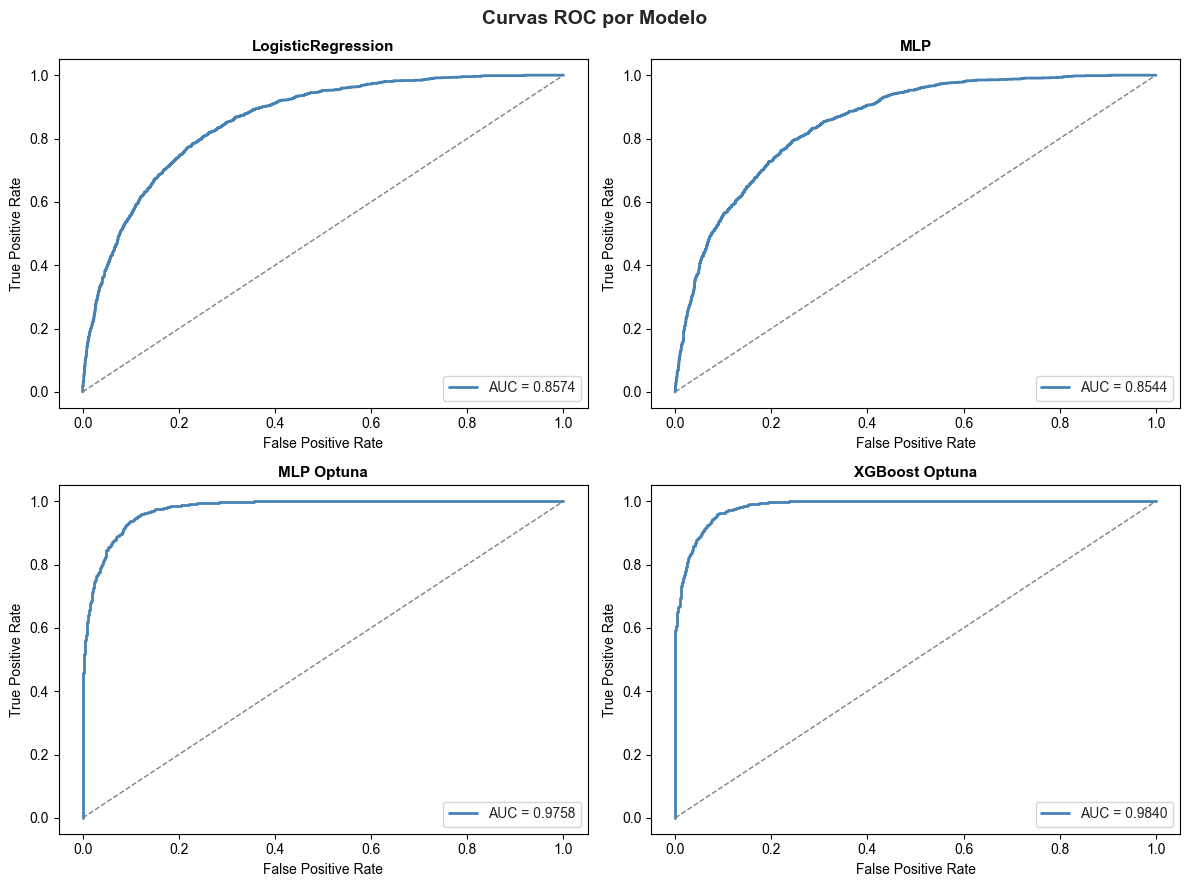

In [10]:
roc_fig = plot_roc_curves_grid(oof_predictions, show=True)


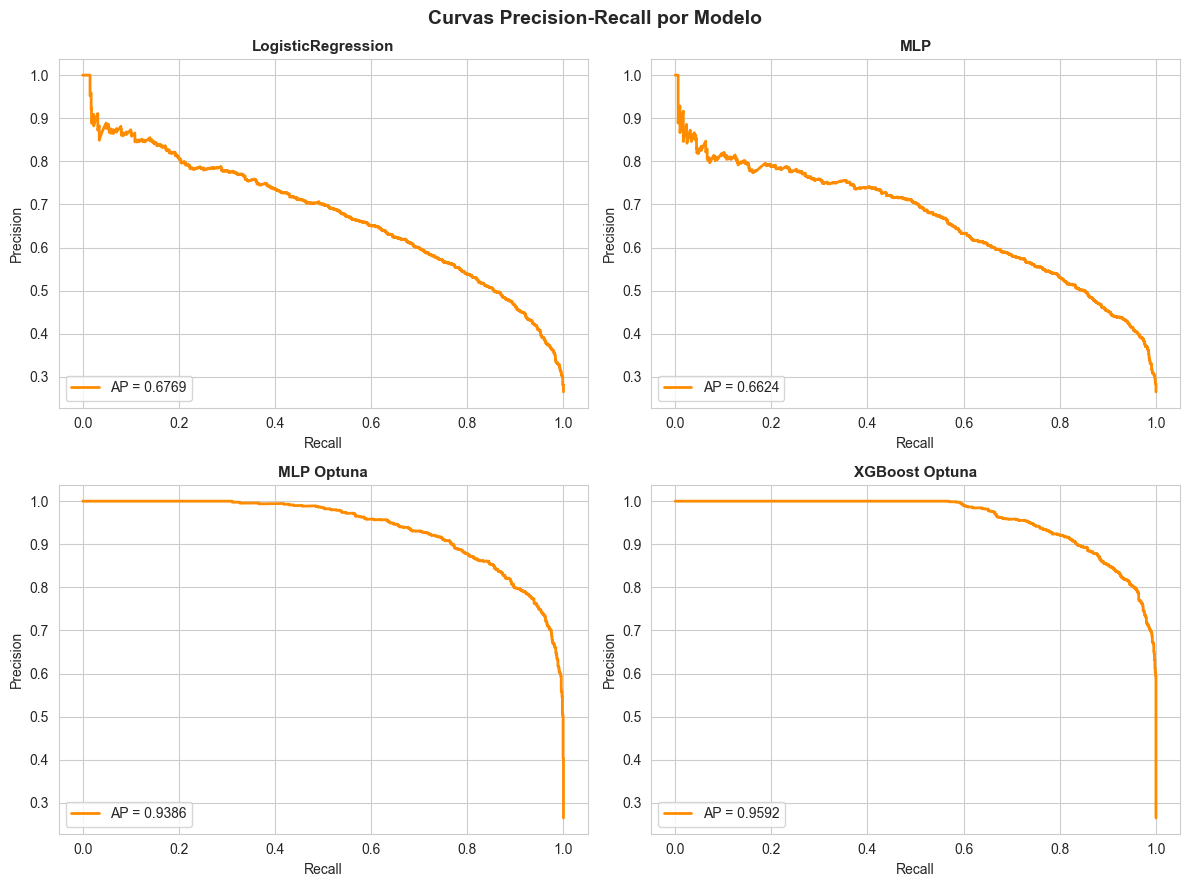

In [11]:
pr_fig = plot_pr_curves_grid(oof_predictions, show=True)


In [12]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['roc_pr'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Curvas ROC e Precision-Recall geradas a partir de probabilidades OOF no conjunto de desenvolvimento.',
    },
):
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_roc',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(roc_fig, 'roc_curves_grid.png')))
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03,
        'nb03_curva_pr',
        nested=True,
        tags={**NB03_BASE_TAGS},
    ):
        mlflow.log_artifact(str(save_figure_temp(pr_fig, 'pr_curves_grid.png')))


#### Learning Curves

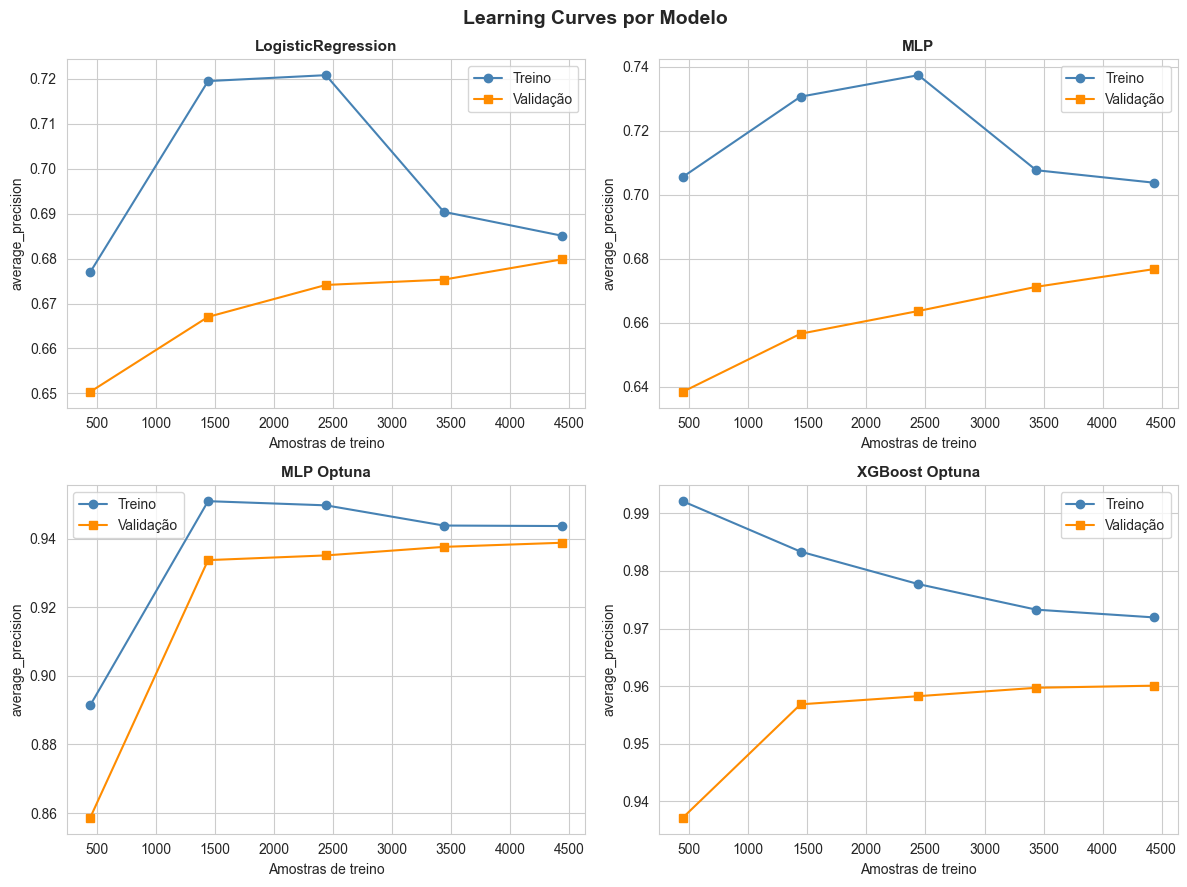

In [13]:
learning_curve_fig = plot_learning_curves_grid(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    show=True,
)


In [14]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['learning'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Learning curves para diagnóstico de comportamento treino vs validação dos modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(learning_curve_fig, 'learning_curves_grid.png')))


### Matriz de Confusão

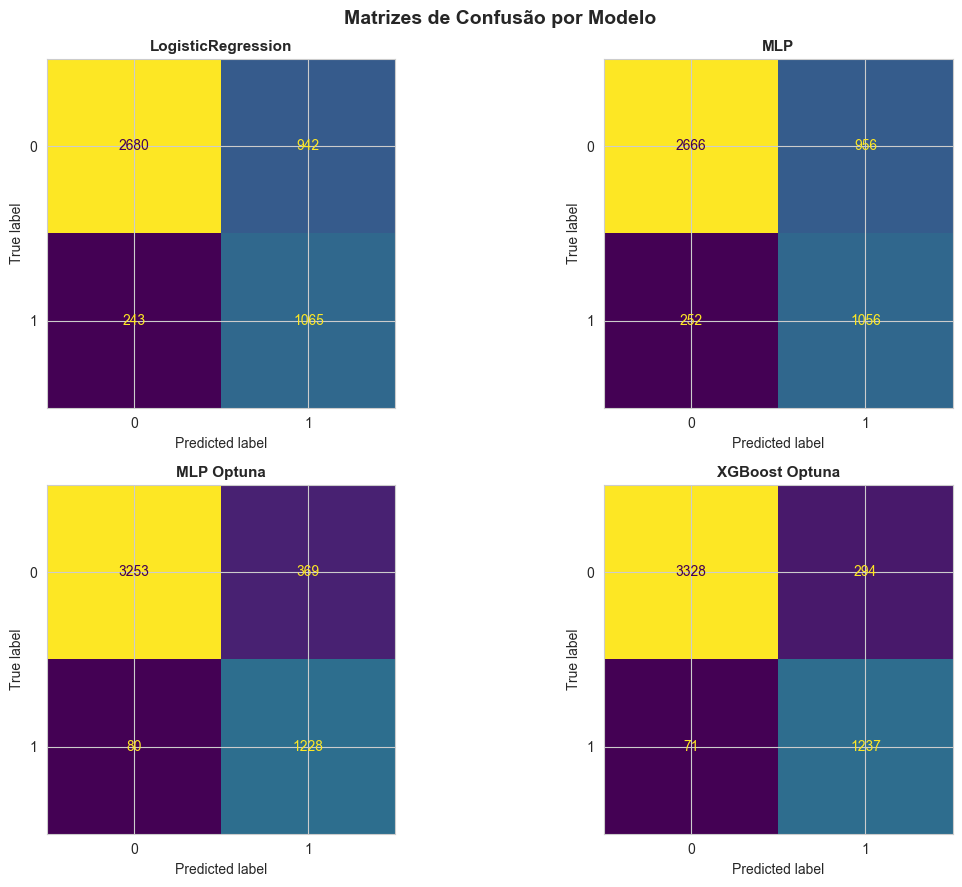

In [15]:
confusion_matrix_fig = plot_confusion_matrices_grid(
    oof_predictions,
    threshold=0.5,
    show=True,
)


In [16]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['confusion'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Matrizes de confusão OOF com threshold padrão de 0.5 para os modelos comparados.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(confusion_matrix_fig, 'confusion_matrices_grid.png')))


### Checagem de Calibração

#### Reliability Curve

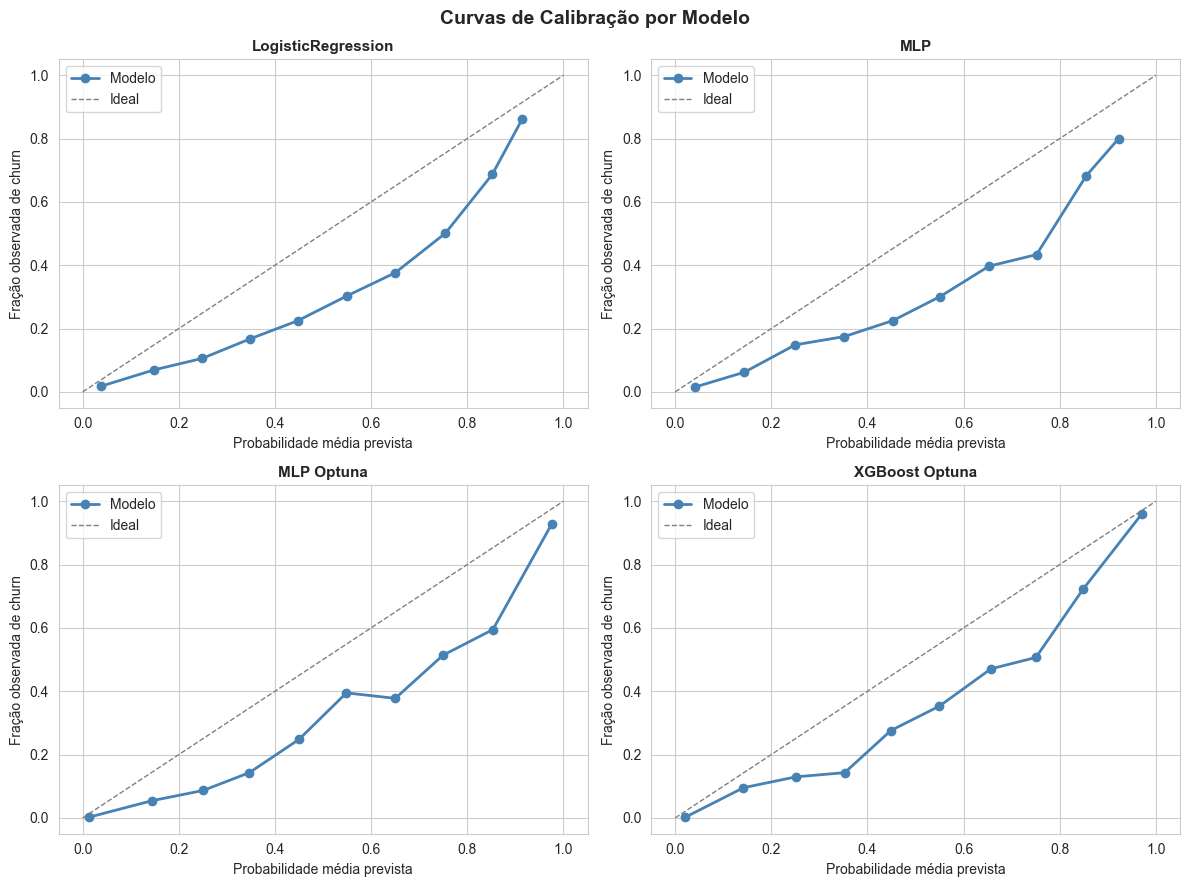

In [17]:
calibration_curve_fig = plot_calibration_curves_grid(
    oof_predictions,
    n_bins=10,
    show=True,
)


In [18]:
calibration_summary = summarize_calibration_for_models(
    oof_predictions,
    n_bins=10,
)

display(calibration_summary.round(6))


,modelo,brier_score,ece
0,LogisticRegression,0.159229,0.141339
1,MLP,0.162267,0.145398
2,MLP Optuna,0.066327,0.063391
3,XGBoost Optuna,0.051794,0.045806


In [19]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_metrics'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Métricas diagnósticas de calibração (Brier Score e ECE) para os modelos comparados.',
    },
):
    for row in calibration_summary.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_calibration_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'brier_score': row['brier_score'],
                    'ece': row['ece'],
                }
            )


In [20]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['calibration_curve'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Reliability curves geradas a partir das probabilidades OOF dos modelos em comparação.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(calibration_curve_fig, 'calibration_curves_grid.png')))


#### Histograma de probabilidades

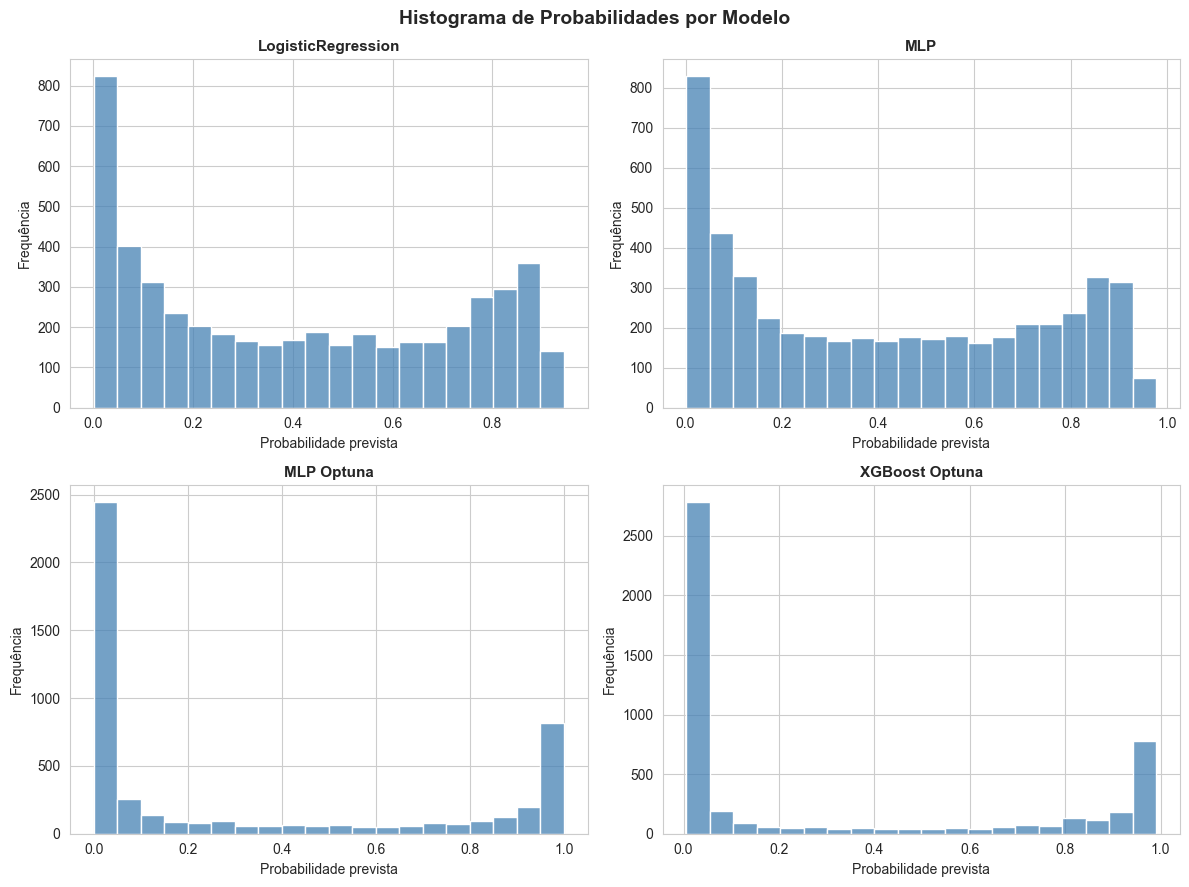

In [21]:
probability_hist_fig = plot_probability_histograms_grid(
    oof_predictions,
    show=True,
)


In [22]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['prob_hist'],
    tags={
        **NB03_BASE_TAGS,
        'mlflow.note.content': 'Histogramas de probabilidade para inspeção da distribuição dos scores OOF por modelo.',
    },
):
    mlflow.log_artifact(str(save_figure_temp(probability_hist_fig, 'probability_histograms_grid.png')))


### Análise Econômica

#### Cenários a serem explorados

- p puro
- p ajustado por peso/beneficio baseado em `CLTV`

#### Métricas Utilizadas

- IEL
- ROI

As descrição das métricas podem ser encontradas em `docs/KPI.md`

#### Premissas
- custo_campanha = 100000
- taxa de retençao = 0.1

#### Cenários a serem explorados

- p puro
- p ajustado por peso/beneficio baseado em `CLTV`

#### Cenário 1 - probabilidades puro

In [ ]:
economic_analysis_pure = build_economic_comparison_table(
    oof_predictions,
    metadata=metadata_train_val,
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_pure.round(2))


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_pure'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_puro',
        'mlflow.note.content': 'An?lise econ?mica com probabilidades OOF puras usando custo por acionamento fixado em 50 BRL e taxa de reten??o de 10%.',
    },
):
    log_dataframe_artifact(economic_analysis_pure.round(6), 'economic_analysis_puro.csv')
    for row in economic_analysis_pure.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_pure_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_puro',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                    'total_campaign_cost': row['total_campaign_cost'],
                    'activation_cost': row['activation_cost'],
                }
            )
            log_dataframe_artifact(
                oof_predictions[model_name].copy(),
                build_artifact_name('oof_prob', model_name, 'csv'),
            )


#### Cenário 2 - probabilidades ponderadas por CLTV

In [25]:
cltv_sample_weight = metadata_train_val.loc[X_train_val.index, 'CLTV']

oof_predictions_cltv = generate_oof_predictions_by_model(
    comparison_models,
    X=X_train_val,
    y=y_train_val,
    cv=cv,
    sample_weight=cltv_sample_weight,
)

{
    model_name: oof_df.head()
    for model_name, oof_df in oof_predictions_cltv.items()
}


{'LogisticRegression':    row_index  fold  y_true     proba  pred_0_5               model
 0          0     6       1  0.621886         1  LogisticRegression
 1          1    10       1  0.551513         1  LogisticRegression
 2          2     8       1  0.678326         1  LogisticRegression
 3          4     2       1  0.325361         0  LogisticRegression
 4          6     1       1  0.890667         1  LogisticRegression,
 'MLP':    row_index  fold  y_true     proba  pred_0_5 model
 0          0     6       1  0.573664         1   MLP
 1          1    10       1  0.658090         1   MLP
 2          2     8       1  0.719524         1   MLP
 3          4     2       1  0.233631         0   MLP
 4          6     1       1  0.896602         1   MLP,
 'MLP Optuna':    row_index  fold  y_true     proba  pred_0_5       model
 0          0     6       1  0.976413         1  MLP Optuna
 1          1    10       1  0.743634         1  MLP Optuna
 2          2     8       1  0.984626      

In [ ]:
economic_analysis_cltv = build_economic_comparison_table(
    oof_predictions_cltv,
    metadata=metadata_train_val,
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
    threshold=0.5,
)

display(economic_analysis_cltv.round(2))


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03,
    NB03_RUN_NAMES['economics_cltv'],
    tags={
        **NB03_BASE_TAGS,
        'scenario': 'p_ponderado_cltv',
        'mlflow.note.content': 'An?lise econ?mica com probabilidades OOF geradas a partir de treino ponderado por CLTV via sample_weight usando custo por acionamento fixado em 50 BRL.',
    },
):
    log_dataframe_artifact(economic_analysis_cltv.round(6), 'economic_analysis_cltv_weighted.csv')
    for row in economic_analysis_cltv.to_dict(orient='records'):
        model_name = row['modelo']
        upstream_run = upstream_runs_by_model[model_name]
        with start_experiment_run(
            MLFLOW_EXPERIMENT_NB03,
            f"nb03_economics_cltv_{model_name.lower().replace(' ', '_')}",
            nested=True,
            tags={
                **NB03_BASE_TAGS,
                'scenario': 'p_ponderado_cltv',
                'upstream_run_id': upstream_run.info.run_id,
            },
        ):
            log_metrics_safe(
                {
                    'iel': row['iel'],
                    'roi': row['roi'],
                    'vr': row['vr'],
                    'vrec': row['vrec'],
                    'vp': row['vp'],
                    'vd': row['vd'],
                    'total_campaign_cost': row['total_campaign_cost'],
                    'activation_cost': row['activation_cost'],
                }
            )
            log_dataframe_artifact(
                oof_predictions_cltv[model_name].copy(),
                build_artifact_name('oof_prob_cltv', model_name, 'csv'),
            )


#### Conclusão

- Nota-se uma pequena melhora operacional em FP e VD, porém não foi suficiente;
- O modelo deixa passar mais churns valiosos (FN subiu e VP subiu bastante);
- a ponderação por sample_weight não ajudou de forma consistente, o cenário p puro é melhor;
- a ponderação trouxe resultados positivos em outros modelos como a regressão logística, o que sugere que o efeito depende muito da arquitetura.
- a recomendação final é manter a abordagem p puro e utilizar CLTV na priorização da campanha por rankeamento de score;

## Performance do Modelo MLP (produção)

In [ ]:
MLFLOW_EXPERIMENT_NB03_PROD = 'tc-f1-nb03-MLP-production-performance'
ensure_experiment(MLFLOW_EXPERIMENT_NB03_PROD)

NB03_PROD_BASE_TAGS = {
    'source_notebook': '03_modelo_mvp',
    'phase': 'production_simulation',
    'comparison_scope': 'holdout',
    'model_name': 'MLP Optuna',
    'upstream_run_id': run_registry['mlp_optuna'].info.run_id,
}

NB03_PROD_RUN_NAMES = {
    'threshold': 'nb03_mlp_threshold_optimization',
    'stress_retention': 'nb03_mlp_retention_roi_sensitivity',
    'stress_heatmap': 'nb03_mlp_campaign_retention_roi_heatmap',
    'holdout': 'nb03_mlp_holdout_performance',
    'shap': 'nb03_mlp_holdout_shap',
    'fairness': 'nb03_mlp_holdout_fairness',
}

mlp_optuna_estimator = comparison_models['MLP Optuna']
mlp_optuna_oof = oof_predictions['MLP Optuna'].copy()
mlp_optuna_cltv = metadata_train_val.loc[mlp_optuna_oof['row_index'], 'CLTV'].to_numpy(dtype=float)

production_run_blueprint = pd.DataFrame(
    [
        {'bloco': key, 'run_name': value}
        for key, value in NB03_PROD_RUN_NAMES.items()
    ]
)

display(production_run_blueprint)


### Otimização do Threshold

In [ ]:
threshold_search_df, best_threshold_row = optimize_threshold_for_roi(
    y_true=mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_oof['proba'].to_numpy(dtype=float),
    cltv=mlp_optuna_cltv,
    threshold_grid=np.round(np.arange(0.0, 1.01, 0.01), 2),
    activation_cost=ACTIVATION_COST,
    retention_rate=RETENTION_RATE,
)

best_threshold = float(best_threshold_row['threshold'])
threshold_search_df.head()


In [ ]:
roi_by_threshold_fig = plot_roi_by_threshold(threshold_search_df, show=False)
roi_by_threshold_fig


In [ ]:
threshold_confusion_fig = plot_confusion_matrix_threshold_comparison(
    mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    mlp_optuna_oof['proba'].to_numpy(dtype=float),
    threshold_a=0.5,
    threshold_b=best_threshold,
    labels=('thr=0.50', f'thr={best_threshold:.2f}'),
    show=False,
)
threshold_confusion_fig


In [ ]:
threshold_best_metrics_df = pd.DataFrame([best_threshold_row]).round(6)
threshold_reference_rows = economic_analysis_pure[
    economic_analysis_pure['modelo'].isin(['LogisticRegression', 'MLP', 'MLP Optuna'])
].copy()
threshold_summary_df = build_threshold_comparison_summary(
    threshold_metrics=best_threshold_row,
    reference_rows=threshold_reference_rows,
).round(6)

display(threshold_best_metrics_df)
display(threshold_summary_df)


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['threshold'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'threshold_optimization',
        'mlflow.note.content': 'Otimiza??o do threshold da MLP Optuna com base em ROI no conjunto de desenvolvimento usando custo por acionamento fixado em 50 BRL.',
    },
):
    log_metrics_safe(
        {
            'best_threshold': best_threshold,
            'iel': float(best_threshold_row['iel']),
            'roi': float(best_threshold_row['roi']),
            'vr': float(best_threshold_row['vr']),
            'vrec': float(best_threshold_row['vrec']),
            'vp': float(best_threshold_row['vp']),
            'vd': float(best_threshold_row['vd']),
            'total_campaign_cost': float(best_threshold_row['total_campaign_cost']),
            'activation_cost': float(best_threshold_row['activation_cost']),
            'pr_auc': float(best_threshold_row['pr_auc']),
            'roc_auc': float(best_threshold_row['roc_auc']),
            'recall': float(best_threshold_row['recall']),
            'precision': float(best_threshold_row['precision']),
            'f1_score': float(best_threshold_row['f1_score']),
        }
    )
    log_dataframe_artifact(threshold_search_df.round(6), 'mlp_optuna_threshold_search.csv')
    log_dataframe_artifact(threshold_best_metrics_df.round(6), 'mlp_optuna_best_threshold_metrics.csv')
    log_dataframe_artifact(threshold_summary_df.round(6), 'mlp_optuna_threshold_summary.csv')
    mlflow.log_artifact(str(save_figure_temp(roi_by_threshold_fig, 'mlp_optuna_roi_by_threshold.png')))
    mlflow.log_artifact(
        str(
            save_figure_temp(
                threshold_confusion_fig,
                'mlp_optuna_confusion_threshold_compare.png',
            )
        )
    )


### Stress-Test: Retenção x ROI

In [ ]:
retention_roi_df = build_retention_roi_table(
    y_true=mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_oof['proba'].to_numpy(dtype=float),
    cltv=mlp_optuna_cltv,
    threshold=best_threshold,
    activation_cost=ACTIVATION_COST,
    retention_values=np.round(np.arange(0.0, 1.01, 0.1), 2),
)

display(retention_roi_df.round(4))


In [ ]:
retention_roi_fig = plot_retention_vs_roi(retention_roi_df, show=False)
retention_roi_fig


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['stress_retention'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'stress_test',
        'analysis_type': 'retention_roi_sensitivity',
        'mlflow.note.content': 'An?lise de sensibilidade do ROI da MLP Optuna variando a taxa de reten??o com custo por acionamento fixado em 50 BRL.',
    },
):
    mlflow.log_param('best_threshold', best_threshold)
    mlflow.log_param('activation_cost', ACTIVATION_COST)
    log_dataframe_artifact(retention_roi_df.round(6), 'mlp_optuna_retention_roi_sensitivity.csv')
    mlflow.log_artifact(str(save_figure_temp(retention_roi_fig, 'mlp_optuna_retention_vs_roi.png')))


### Campanha x Retenção x ROI (heatmap)

In [ ]:
activation_cost_grid = [25, 50, 75, 100, 125, 150]
retencao = [0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]


In [ ]:
campaign_retention_roi_grid = build_campaign_retention_roi_grid(
    y_true=mlp_optuna_oof['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_oof['proba'].to_numpy(dtype=float),
    cltv=mlp_optuna_cltv,
    threshold=best_threshold,
    activation_cost_values=activation_cost_grid,
    retention_values=retencao,
)

campaign_retention_roi_heatmap_fig = plot_roi_heatmap(campaign_retention_roi_grid, show=False)
campaign_retention_roi_heatmap_fig


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['stress_heatmap'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'stress_test',
        'analysis_type': 'campaign_retention_roi_heatmap',
        'mlflow.note.content': 'Heatmap de ROI da MLP Optuna variando custo por acionamento e taxa de reten??o com threshold ?timo fixado.',
    },
):
    mlflow.log_param('best_threshold', best_threshold)
    log_dataframe_artifact(campaign_retention_roi_grid.round(6), 'mlp_optuna_campaign_retention_roi_grid.csv')
    mlflow.log_artifact(
        str(
            save_figure_temp(
                campaign_retention_roi_heatmap_fig,
                'mlp_optuna_campaign_retention_roi_heatmap.png',
            )
        )
    )


### Análise no Holdout

In [ ]:
mlp_optuna_final_estimator, mlp_optuna_holdout = fit_final_estimator_and_generate_predictions(
    estimator=mlp_optuna_estimator,
    X_train=X_train_val,
    y_train=y_train_val,
    X_test=X_test,
    y_test=y_test,
    threshold=best_threshold,
    model_name='MLP Optuna',
)

holdout_technical_metrics = compute_holdout_technical_metrics(
    y_true=mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    threshold=best_threshold,
)
holdout_economic_metrics = build_retention_roi_table(
    y_true=mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    y_prob=mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    cltv=metadata_test.loc[mlp_optuna_holdout['row_index'], 'CLTV'].to_numpy(dtype=float),
    threshold=best_threshold,
    activation_cost=ACTIVATION_COST,
    retention_values=[RETENTION_RATE],
).iloc[0].to_dict()

selected_feature_names = extract_selected_feature_names(mlp_optuna_final_estimator, X_train_val)
holdout_metrics_df = pd.DataFrame(
    [
        {
            'modelo': 'MLP Optuna',
            'threshold': best_threshold,
            **holdout_technical_metrics,
            **holdout_economic_metrics,
        }
    ]
).round(6)

selected_features_mlp_optuna = pd.DataFrame(
    {
        'feature_rank': np.arange(1, len(selected_feature_names) + 1),
        'feature_name': selected_feature_names,
    }
)

display(holdout_metrics_df)
display(selected_features_mlp_optuna)


In [ ]:
holdout_confusion_fig = plot_single_confusion_matrix(
    mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    mlp_optuna_holdout['y_pred'].to_numpy(dtype=int),
    title=f'MLP Optuna Holdout (thr={best_threshold:.2f})',
    show=False,
)



In [ ]:
holdout_pr_roc_fig = plot_holdout_pr_roc_subplot(
    mlp_optuna_holdout['y_true'].to_numpy(dtype=int),
    mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    title='MLP Optuna Holdout',
    show=False,
)



In [ ]:
holdout_probability_fig = plot_single_probability_histogram(
    mlp_optuna_holdout['proba'].to_numpy(dtype=float),
    title='Histograma de Probabilidades - Holdout',
    show=False,
)


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['holdout'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_evaluation',
        'mlflow.note.content': 'Avalia??o final da MLP Optuna no holdout com threshold ?timo fixado e custo por acionamento de 50 BRL.',
    },
):
    log_metrics_safe(
        {
            'best_threshold': best_threshold,
            'pr_auc': float(holdout_technical_metrics['pr_auc']),
            'roc_auc': float(holdout_technical_metrics['roc_auc']),
            'recall': float(holdout_technical_metrics['recall']),
            'precision': float(holdout_technical_metrics['precision']),
            'f1_score': float(holdout_technical_metrics['f1_score']),
            'iel': float(holdout_economic_metrics['iel']),
            'roi': float(holdout_economic_metrics['roi']),
            'vr': float(holdout_economic_metrics['vr']),
            'vrec': float(holdout_economic_metrics['vrec']),
            'vp': float(holdout_economic_metrics['vp']),
            'vd': float(holdout_economic_metrics['vd']),
            'total_campaign_cost': float(holdout_economic_metrics['total_campaign_cost']),
            'activation_cost': float(holdout_economic_metrics['activation_cost']),
        }
    )
    log_dataframe_artifact(holdout_metrics_df.round(6), 'mlp_optuna_holdout_metrics.csv')
    log_dataframe_artifact(selected_features_mlp_optuna, 'mlp_optuna_selected_features.csv')
    log_dataframe_artifact(mlp_optuna_holdout.round(6), 'mlp_optuna_holdout_predictions.csv')
    mlflow.log_artifact(str(save_figure_temp(holdout_confusion_fig, 'mlp_optuna_holdout_confusion_matrix.png')))
    mlflow.log_artifact(str(save_figure_temp(holdout_pr_roc_fig, 'mlp_optuna_holdout_pr_roc.png')))
    mlflow.log_artifact(str(save_figure_temp(holdout_probability_fig, 'mlp_optuna_holdout_probability_hist.png')))


### Interpretabilidade da Rede Neural (SHAP)

In [ ]:
try:
    shap_payload = compute_shap_summary_payload(
        fitted_estimator=mlp_optuna_final_estimator,
        X_reference=X_train_val,
        sample_size=min(200, len(X_train_val)),
        background_size=50,
        random_state=42,
    )
    shap_summary_fig = plot_shap_summary_subplot(
        shap_payload['shap_values'],
        shap_payload['transformed_values'],
        shap_payload['feature_names'],
        show=False,
    )
    shap_summary_fig
except ModuleNotFoundError as exc:
    shap_payload = None
    shap_summary_fig = None
    print(str(exc))


In [ ]:
if shap_summary_fig is None:
    print('SHAP n?o foi logado porque a depend?ncia n?o est? dispon?vel no ambiente atual.')
else:
    with start_experiment_run(
        MLFLOW_EXPERIMENT_NB03_PROD,
        NB03_PROD_RUN_NAMES['shap'],
        tags={
            **NB03_PROD_BASE_TAGS,
            'stage': 'holdout_explainability',
            'mlflow.note.content': 'Explicabilidade do modelo final MLP Optuna no holdout usando SHAP sobre a representa??o transformada do pipeline.',
        },
    ):
        mlflow.log_artifact(str(save_figure_temp(shap_summary_fig, 'mlp_optuna_holdout_shap_summary.png')))


### Análise de Fairness

In [ ]:
fairness_features = ['Senior Citizen', 'Partner', 'Dependents', 'Contract']
fairness_reports = build_fairness_reports_bundle(
    y_true=mlp_optuna_holdout['y_true'],
    y_pred=mlp_optuna_holdout['y_pred'],
    X_sensitive=X_test[fairness_features],
    features=fairness_features,
)

fairness_by_group_df, fairness_summary_df = consolidate_fairness_reports(fairness_reports)


In [ ]:
for feature_name in fairness_features:
    print(f'Feature: {feature_name}')
    display(fairness_reports[feature_name]['by_group'].round(6))
    display(fairness_reports[feature_name]['summary'].round(6))
    display(fairness_reports[feature_name]['fairness_metrics'].round(6))


In [ ]:
fairness_figures = {
    feature_name: plot_fairness_feature_subplot(
        report['by_group'],
        feature_name=feature_name,
        show=False,
    )
    for feature_name, report in fairness_reports.items()
}

for feature_name, fig in fairness_figures.items():
    print(f'Fairness - {feature_name}')
    display(fig)


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    NB03_PROD_RUN_NAMES['fairness'],
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_fairness',
        'mlflow.note.content': 'An?lise de fairness por grupos sens?veis e contratuais para a MLP Optuna no holdout final, com artefatos separados por feature.',
    },
):
    for feature_name, report in fairness_reports.items():
        feature_slug = feature_name.lower().replace(' ', '_')
        log_dataframe_artifact(
            report['by_group'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_by_group.csv',
        )
        log_dataframe_artifact(
            report['summary'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_summary.csv',
        )
        log_dataframe_artifact(
            report['fairness_metrics'].round(6),
            f'mlp_optuna_fairness_{feature_slug}_metrics.csv',
        )

    log_dataframe_artifact(fairness_by_group_df.round(6), 'mlp_optuna_fairness_by_group_consolidated.csv')
    log_dataframe_artifact(fairness_summary_df.round(6), 'mlp_optuna_fairness_summary_consolidated.csv')


In [ ]:
with start_experiment_run(
    MLFLOW_EXPERIMENT_NB03_PROD,
    f"{NB03_PROD_RUN_NAMES['fairness']}_plots",
    tags={
        **NB03_PROD_BASE_TAGS,
        'stage': 'holdout_fairness',
        'artifact_type': 'plots',
    },
):
    for feature_name, fig in fairness_figures.items():
        feature_slug = feature_name.lower().replace(' ', '_')
        mlflow.log_artifact(
            str(save_figure_temp(fig, f'mlp_optuna_fairness_{feature_slug}.png'))
        )
